In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Q5: Given Raman spectral data measured from six bacterial species, please build an LDA model to separate the six species.

In [2]:
### load data
data = pd.read_csv('classification_spec.csv', header=None)
data

,0,1,2,3,4,5,6,7,8,9,...,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375
0,400.000000,402.000000,404.000000,406.000000,408.000000,410.000000,412.000000,414.000000,416.000000,418.000000,...,3132.000000,3134.000000,3136.000000,3138.000000,3140.000000,3142.000000,3144.000000,3146.000000,3148.000000,3150.000000
1,48.707691,43.903876,27.073055,24.885715,35.267428,28.747168,10.897972,-2.785735,-2.026663,16.584663,...,1.461492,9.578739,9.885035,2.738687,-3.678894,-1.371132,10.765852,14.747017,14.176111,12.472059
2,64.819631,71.834878,76.930678,72.947486,61.356842,52.731382,47.498447,42.952666,38.679265,34.216845,...,12.914044,23.771412,9.624409,16.555127,19.294024,11.702179,29.214662,16.941762,15.243206,24.001155
3,63.806536,53.339466,69.535666,81.203678,69.883255,57.005251,53.167996,58.120419,56.786181,30.006636,...,-1.126209,4.635422,5.610834,17.026027,19.112369,4.716200,-4.503231,5.153161,17.483822,15.932627
4,71.808476,69.759851,61.623413,47.671625,35.815485,36.499904,33.890724,13.311474,-0.071387,19.149030,...,16.671954,9.873609,-0.059435,-0.503562,9.518001,18.360571,18.011997,13.706083,11.249410,10.961979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,62.912643,55.230136,47.776575,58.476725,79.586173,77.035613,58.505852,44.106047,41.144327,49.485840,...,20.368072,30.955161,18.905626,7.022299,5.282636,10.749624,20.061126,12.168057,11.047212,14.458266
497,72.889767,67.765892,61.674507,61.187316,67.015179,73.109183,73.306217,64.523989,57.408627,61.557496,...,5.571161,15.184689,25.312820,21.031022,11.163505,12.217696,19.557979,9.164086,-6.000943,-3.263111
498,56.354891,65.886429,65.962519,51.977451,41.932582,46.059463,47.799283,38.419786,25.620396,15.818723,...,25.136068,19.389890,1.606457,-1.834222,11.175519,22.766656,8.219274,4.519288,12.655316,9.576864
499,47.873533,30.104165,10.732846,7.595859,18.478769,21.598678,17.004571,11.717571,12.241276,21.636772,...,3.417620,5.780569,1.604167,4.562219,9.356381,7.006262,12.550253,5.948657,-0.716595,4.211659


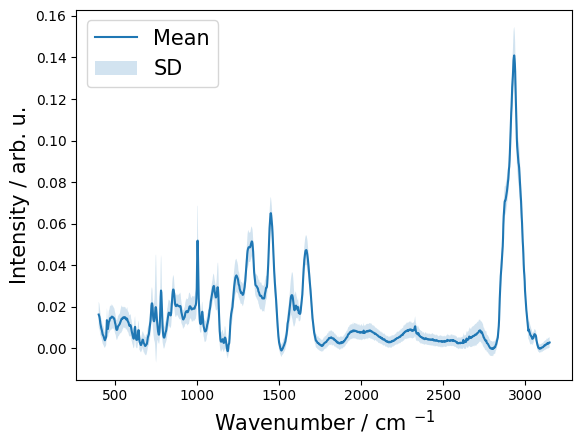

In [3]:
### plot data
wn = np.array(data.iloc[0, :])
spec = data.iloc[1:, :]


### normalization (l2, vector normalization)
spec = np.row_stack([row/np.sqrt(np.sum(row**2)) for i, row in spec.iterrows()])

spec_mean = spec.mean(axis=0)
spec_sd = spec.std(axis=0)

plt.plot(wn, spec_mean, label='Mean')
plt.fill_between(wn, spec_mean - spec_sd, 
                 spec_mean + spec_sd, 
                 alpha = 0.2, label='SD')
plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)
plt.legend(fontsize=15)

In [4]:
### load labels
meta = pd.read_csv('classification_meta.csv', header=0)
meta

,label,batch
0,S-cohnii,3_Batch
1,E-coli,6_Batch
2,R-terrigena,9_Batch
3,P-stutzeri,7_Batch
4,S-warneri,5_Batch
...,...,...
495,R-terrigena,3_Batch
496,S-cohnii,7_Batch
497,P-stutzeri,1_Batch
498,L-innocua,9_Batch


In [5]:
labels = np.array(meta['label'])
labels

array(['S-cohnii', 'E-coli', 'R-terrigena', 'P-stutzeri', 'S-warneri',
       'S-cohnii', 'R-terrigena', 'S-cohnii', 'R-terrigena', 'S-warneri',
       'S-warneri', 'P-stutzeri', 'L-innocua', 'S-warneri', 'L-innocua',
       'E-coli', 'R-terrigena', 'S-warneri', 'S-cohnii', 'S-cohnii',
       'R-terrigena', 'S-cohnii', 'S-warneri', 'L-innocua', 'S-warneri',
       'S-cohnii', 'S-cohnii', 'L-innocua', 'S-cohnii', 'S-warneri',
       'S-warneri', 'S-cohnii', 'P-stutzeri', 'R-terrigena', 'S-cohnii',
       'P-stutzeri', 'P-stutzeri', 'E-coli', 'S-warneri', 'R-terrigena',
       'R-terrigena', 'E-coli', 'P-stutzeri', 'S-warneri', 'L-innocua',
       'P-stutzeri', 'L-innocua', 'R-terrigena', 'P-stutzeri', 'S-cohnii',
       'E-coli', 'L-innocua', 'E-coli', 'S-warneri', 'S-cohnii',
       'S-cohnii', 'S-cohnii', 'L-innocua', 'E-coli', 'S-cohnii',
       'S-warneri', 'P-stutzeri', 'P-stutzeri', 'S-cohnii', 'L-innocua',
       'P-stutzeri', 'R-terrigena', 'S-cohnii', 'R-terrigena', 'E-coli',
 

In [6]:
batches = np.array(meta['batch'])
batches

array(['3_Batch', '6_Batch', '9_Batch', '7_Batch', '5_Batch', '1_Batch',
       '9_Batch', '6_Batch', '5_Batch', '6_Batch', '6_Batch', '6_Batch',
       '5_Batch', '1_Batch', '8_Batch', '3_Batch', '4_Batch', '4_Batch',
       '2_Batch', '2_Batch', '8_Batch', '5_Batch', '1_Batch', '7_Batch',
       '6_Batch', '2_Batch', '5_Batch', '8_Batch', '8_Batch', '1_Batch',
       '7_Batch', '5_Batch', '7_Batch', '1_Batch', '5_Batch', '3_Batch',
       '5_Batch', '9_Batch', '2_Batch', '5_Batch', '5_Batch', '6_Batch',
       '8_Batch', '6_Batch', '9_Batch', '5_Batch', '2_Batch', '5_Batch',
       '8_Batch', '8_Batch', '6_Batch', '6_Batch', '9_Batch', '7_Batch',
       '1_Batch', '3_Batch', '5_Batch', '9_Batch', '9_Batch', '9_Batch',
       '1_Batch', '4_Batch', '5_Batch', '7_Batch', '8_Batch', '9_Batch',
       '1_Batch', '1_Batch', '6_Batch', '3_Batch', '9_Batch', '5_Batch',
       '5_Batch', '9_Batch', '3_Batch', '5_Batch', '5_Batch', '6_Batch',
       '7_Batch', '6_Batch', '3_Batch', '7_Batch', 

In [7]:
uni_labels = np.unique(labels)
uni_labels

array(['E-coli', 'L-innocua', 'P-stutzeri', 'R-terrigena', 'S-cohnii',
       'S-warneri'], dtype=object)

In [8]:
uni_batches = np.unique(batches)
uni_batches

array(['1_Batch', '2_Batch', '3_Batch', '4_Batch', '5_Batch', '6_Batch',
       '7_Batch', '8_Batch', '9_Batch'], dtype=object)

In [9]:
### plot mean spectrum of each group
def plot_mean (wn, spec, labels, uni_labels, figsize=(7, 5), fontsize=12, title='', gap=0.05):
    
    plt.figure(figsize=figsize)
    
    for i, l in enumerate(uni_labels):
        spec_mean = spec[labels==l, :].mean(axis=0)
        spec_std = spec[labels==l, :].std(axis=0)
        plt.plot(wn, spec_mean + i*gap, label=l)
        plt.fill_between(wn, spec_mean + i*gap - spec_sd, 
                         spec_mean + i*gap + spec_sd, 
                         alpha = 0.2)
    plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
    plt.ylabel('Intensity / arb. u.', fontsize=15)
    plt.title(title)
    plt.legend(fontsize=15)

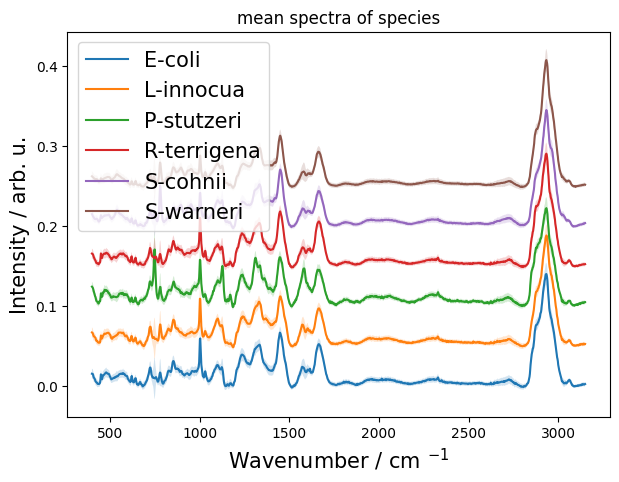

In [10]:
### plot mean of each species (group)
plot_mean(wn, spec, labels, uni_labels, title='mean spectra of species')

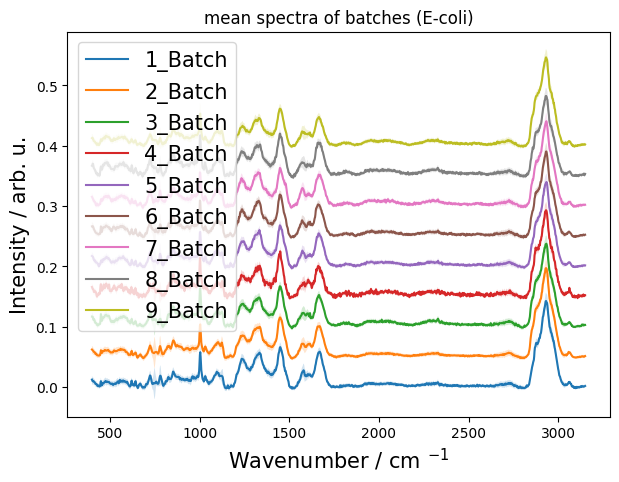

In [11]:
### plot mean of each batch for E-coli
plot_mean(wn, spec[labels=='E-coli', :], batches[labels=='E-coli'], uni_batches, title="mean spectra of batches (E-coli)")

In [12]:
### build LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
model_LDA = LDA().fit(spec, labels)
label_pred = model_LDA.predict(spec)

In [13]:
from sklearn.metrics import confusion_matrix
cmat = confusion_matrix(labels, label_pred)
cmat

array([[78,  0,  0,  3,  0,  0],
       [ 0, 86,  0,  0,  0,  2],
       [ 0,  0, 75,  0,  0,  0],
       [ 1,  0,  0, 74,  0,  0],
       [ 0,  0,  0,  0, 93,  0],
       [ 0,  0,  0,  0,  1, 87]])

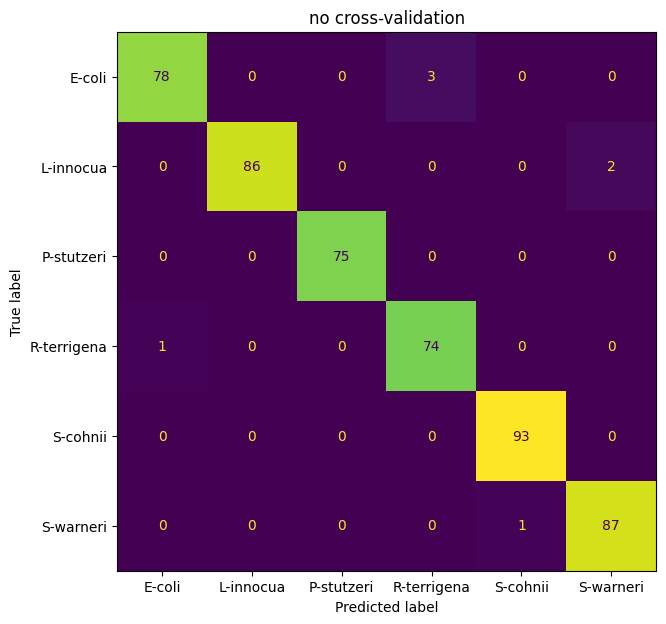

In [14]:
### display confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cmat, display_labels=uni_labels)
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('no cross-validation')
plt.show()

In [15]:
### calculate sensitivity of each group
sens = np.diag(cmat)/np.sum(cmat, axis=1)
sens

array([0.96296296, 0.97727273, 1.        , 0.98666667, 1.        ,
       0.98863636])

In [16]:
### calculate balanced accuracy
from sklearn.metrics import balanced_accuracy_score
bacc = balanced_accuracy_score(labels, label_pred)
bacc

0.9859231200897867

In [17]:
np.mean(sens)

0.9859231200897867

In [18]:
pred_scores = model_LDA.decision_function(spec)
pred_scores.shape

(500, 6)

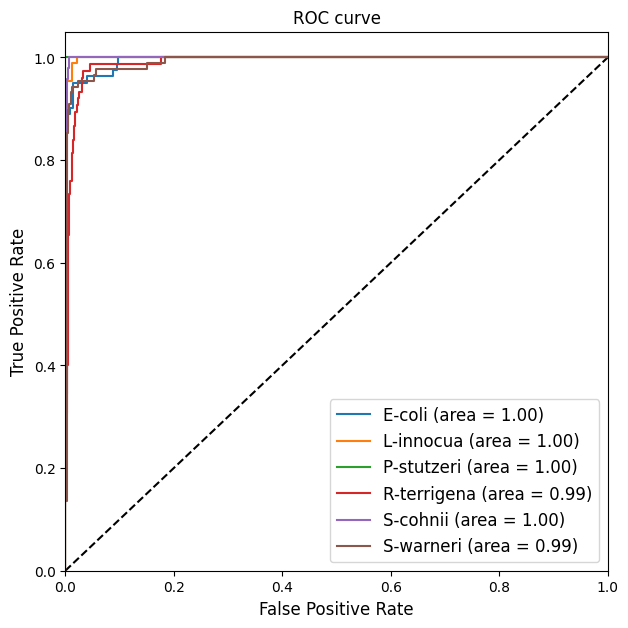

array([0.99504994, 0.99933804, 1.        , 0.99068235, 0.9982299 ,
       0.99227714])

In [19]:
### ROC curve
from sklearn.metrics import roc_curve, auc
pred_scores = model_LDA.decision_function(spec)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--')

aucs = []
for i,l in enumerate(uni_labels):
    fpr, tpr, _ = roc_curve(labels, pred_scores[:, i], pos_label=l)
    roc_auc = auc(fpr, tpr)
    aucs = np.append(aucs, roc_auc)
    plt.plot(fpr, tpr, label=l + ' (area = %0.2f)' % roc_auc)
    
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.title('ROC curve', fontsize=12)
plt.show()
aucs

In [20]:
### define evaluation as function
def my_evaluation(y_true, y_pred, y_scores, cmat_display=True, get_roc=True, figsize=(7, 7), title='', c_max=100, fontsize=12):
    bacc = balanced_accuracy_score(y_true, y_pred)
    cmat = confusion_matrix(y_true, y_pred)
    aucs = []
    if cmat_display:
        disp = ConfusionMatrixDisplay(confusion_matrix=cmat, display_labels=uni_labels)
    
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        disp.plot(ax=ax, colorbar=False)
        disp.im_.set_clim(0, c_max)
        plt.title(title)
        plt.show()
    
    if get_roc:
        
        plt.figure(figsize=(7, 7))
        plt.plot([0, 1], [0, 1], 'k--')

        for i,l in enumerate(np.unique(y_true)):
            fpr, tpr, _ = roc_curve(y_true, y_scores[:, i], pos_label=l)
            roc_auc = auc(fpr, tpr)
            aucs = np.append(aucs, roc_auc)
            plt.plot(fpr, tpr, label=l + ' (area = %0.2f)' % roc_auc)
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('False Positive Rate', fontsize=fontsize)
        plt.ylabel('True Positive Rate', fontsize=fontsize)
        plt.legend(loc="lower right", fontsize=fontsize)
        plt.show()
    return cmat, bacc, np.mean(aucs)

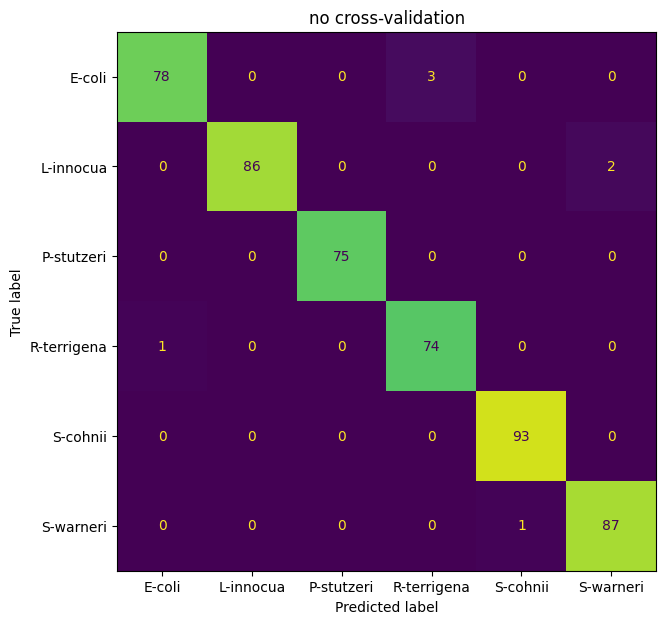

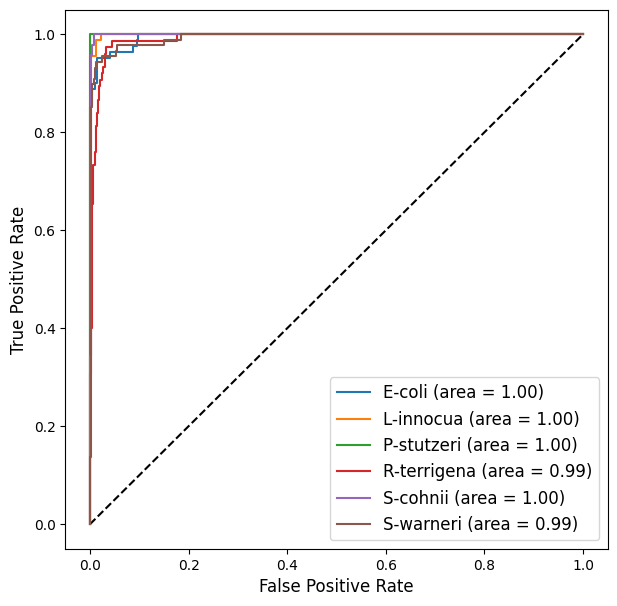

[[78  0  0  3  0  0]
 [ 0 86  0  0  0  2]
 [ 0  0 75  0  0  0]
 [ 1  0  0 74  0  0]
 [ 0  0  0  0 93  0]
 [ 0  0  0  0  1 87]]
0.9859231200897867
0.9959295629794048


In [21]:
cmat1, bacc1, auc1 = my_evaluation(labels, label_pred, pred_scores, title='no cross-validation')
print(cmat1)
print(bacc1)
print(auc1)

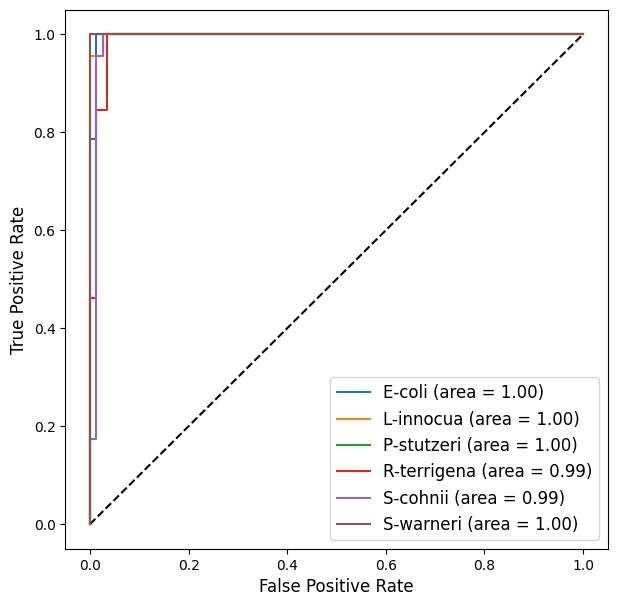

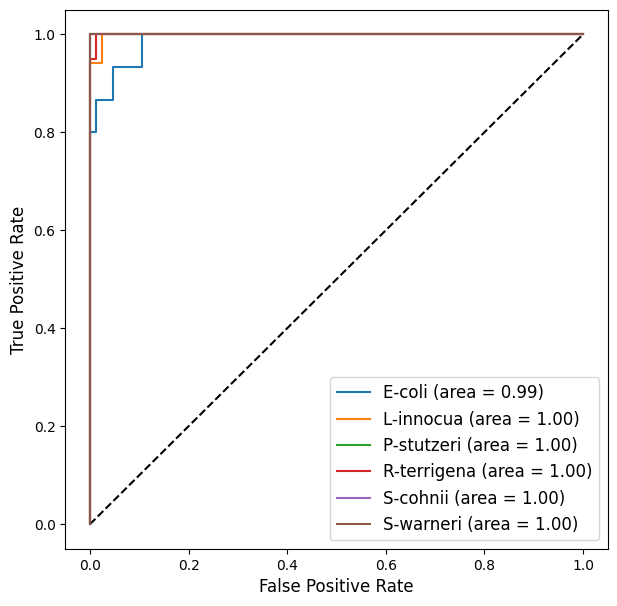

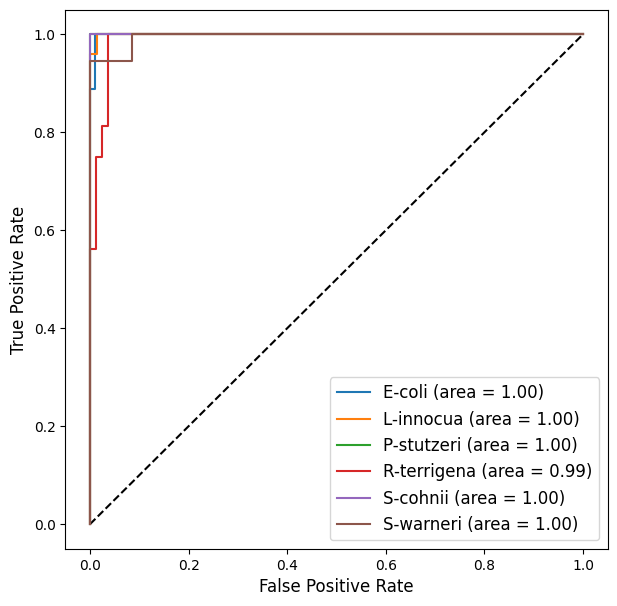

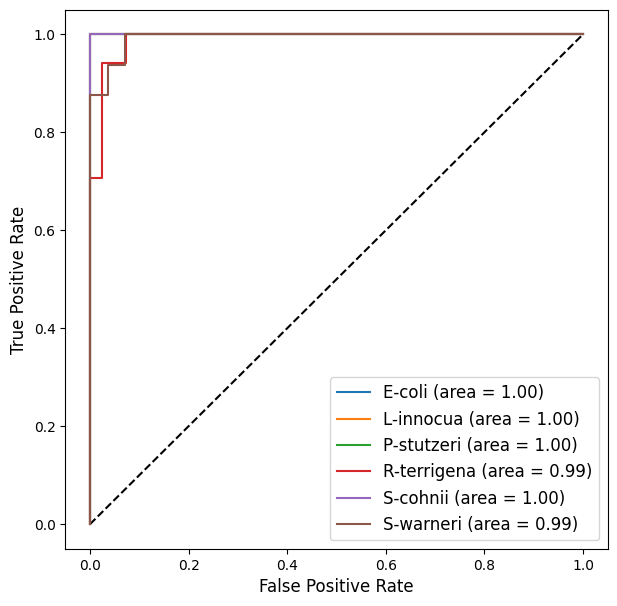

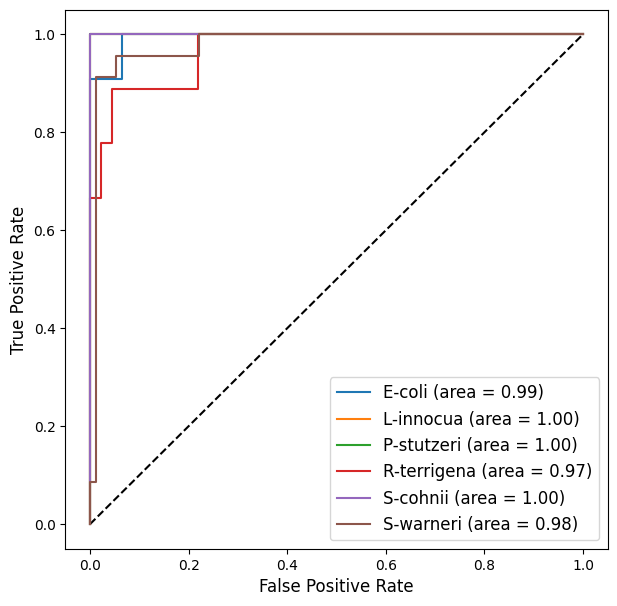

{0: array([[11,  0,  0,  3,  0,  0],
       [ 0, 17,  1,  1,  0,  3],
       [ 0,  0, 16,  0,  0,  0],
       [ 4,  0,  0,  9,  0,  0],
       [ 0,  1,  0,  0, 20,  2],
       [ 0,  0,  0,  0,  0, 12]]), 1: array([[10,  0,  0,  5,  0,  0],
       [ 0, 15,  0,  0,  1,  1],
       [ 0,  0, 12,  0,  0,  0],
       [ 2,  0,  0, 18,  0,  0],
       [ 0,  0,  0,  0, 17,  0],
       [ 0,  1,  0,  0,  1, 17]]), 2: array([[ 7,  0,  0,  2,  0,  0],
       [ 0, 22,  0,  1,  0,  2],
       [ 0,  0, 13,  0,  0,  0],
       [ 6,  0,  0, 10,  0,  0],
       [ 0,  3,  0,  0, 15,  1],
       [ 0,  0,  0,  1,  0, 17]]), 3: array([[10,  0,  0, 11,  0,  0],
       [ 0, 10,  0,  0,  0,  1],
       [ 1,  0, 16,  0,  0,  0],
       [ 5,  0,  0, 12,  0,  0],
       [ 0,  0,  1,  1, 16,  0],
       [ 0,  1,  0,  0,  1, 14]]), 4: array([[17,  0,  0,  5,  0,  0],
       [ 1, 10,  0,  0,  0,  2],
       [ 3,  1, 13,  0,  0,  0],
       [ 3,  0,  0,  6,  0,  0],
       [ 0,  0,  0,  0, 16,  0],
       [ 0,  0,  0,

In [22]:
### classification with cross-validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=1234)

label_pred = np.zeros_like(labels)
cmat_inter = dict()
bacc_inter = np.zeros((5))
auc_inter = np.zeros((5))
for i, (ix_train, ix_test) in enumerate(kf.split(spec)):
    x_train, y_train = spec[ix_train, :], labels[ix_train]
    x_test, y_test = spec[ix_test, :], labels[ix_test]
    
    LDA_CV = LDA()
    LDA_CV.fit(x_train, y_train)
    label_pred[ix_test] = LDA_CV.predict(x_test)
    label_score = LDA_CV.decision_function(x_test)
    cmat_inter[i], bacc_inter[i], auc_inter[i] = my_evaluation(y_test, label_pred[ix_test], pred_scores[ix_test, :], cmat_display=False, title='5-fold cross-validation')

print(cmat_inter)
print(bacc_inter)
print(auc_inter)

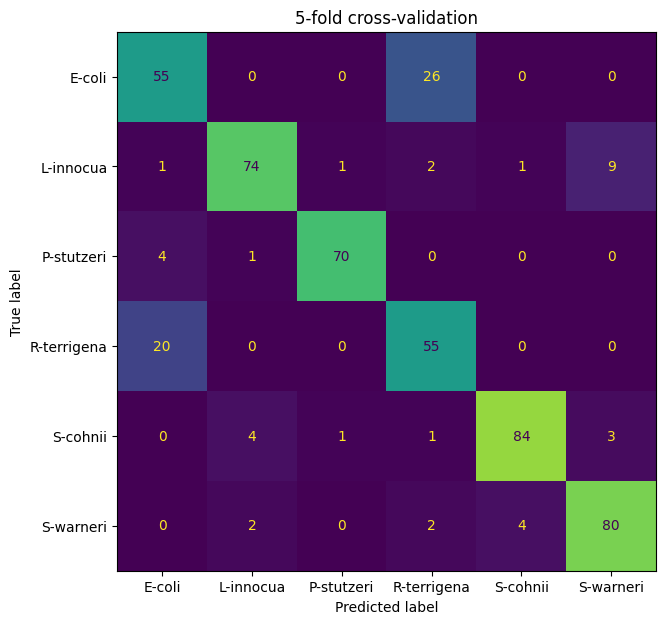

[[55  0  0 26  0  0]
 [ 1 74  1  2  1  9]
 [ 4  1 70  0  0  0]
 [20  0  0 55  0  0]
 [ 0  4  1  1 84  3]
 [ 0  2  0  2  4 80]]
0.8331508031328819


/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [23]:
cmat_all, bacc_all, _ = my_evaluation(labels, label_pred, None, get_roc=False, title='5-fold cross-validation')
print(cmat_all)
print(bacc_all)

['3_Batch']


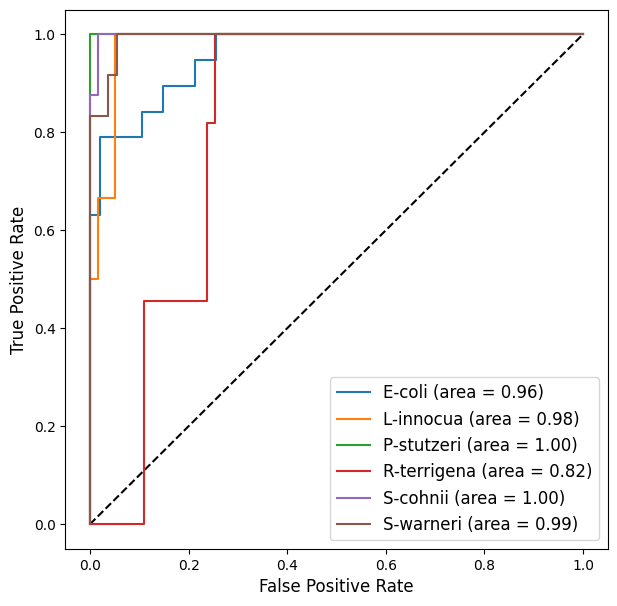

['8_Batch']


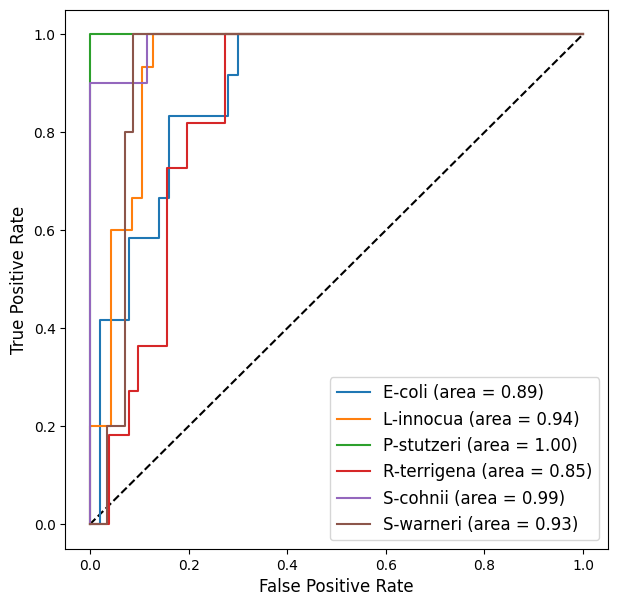

['5_Batch']


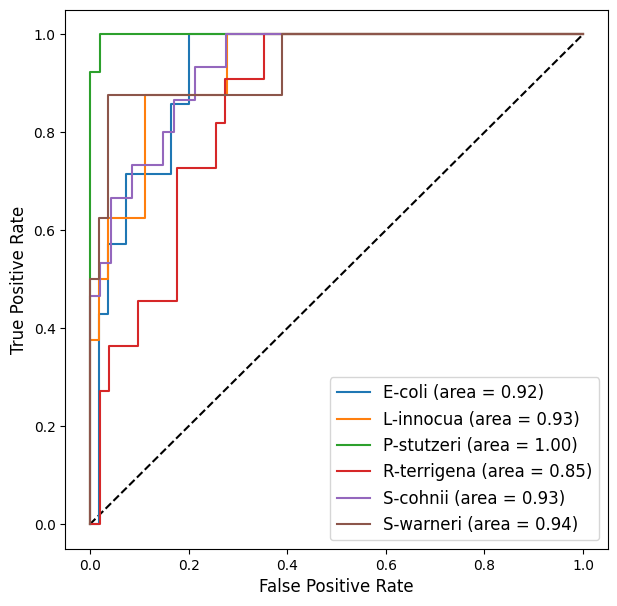

['6_Batch']


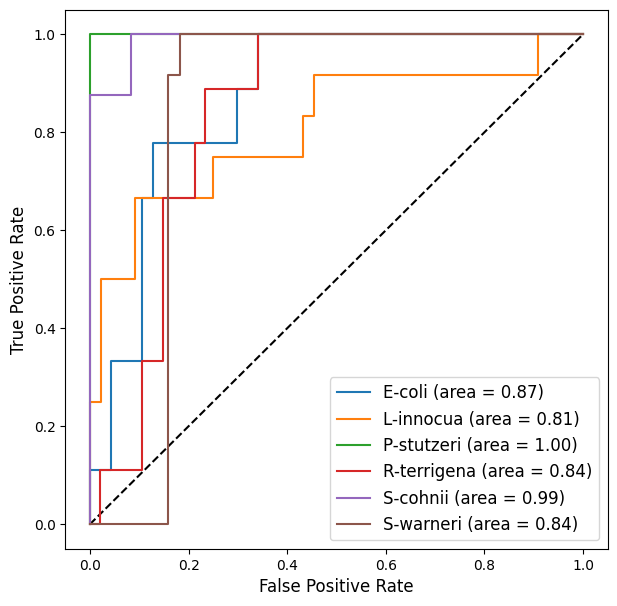

['9_Batch']


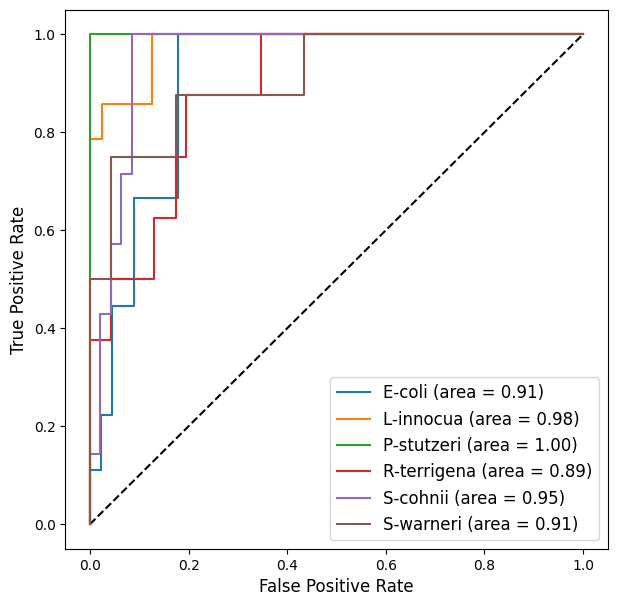

['1_Batch']


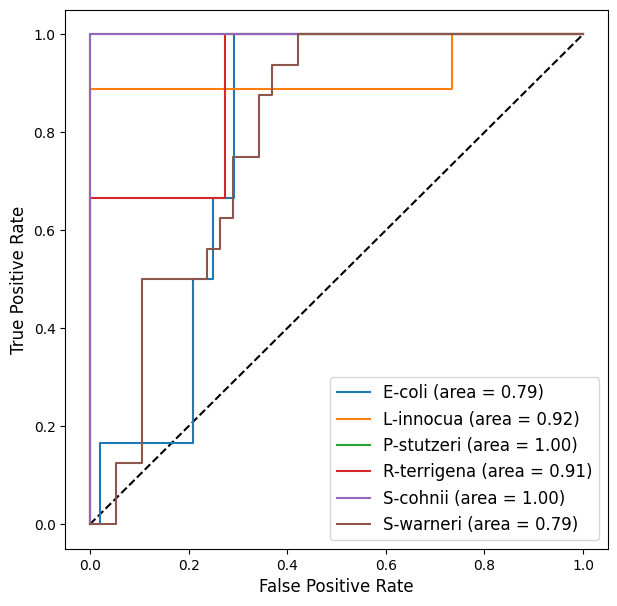

['7_Batch']


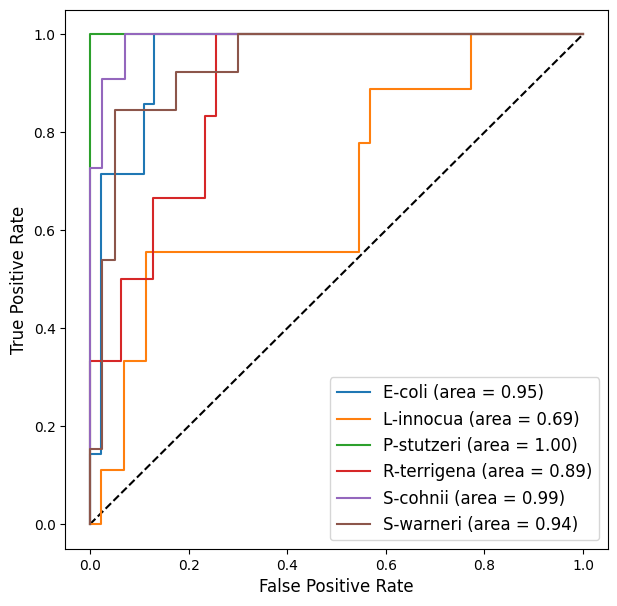

['2_Batch']


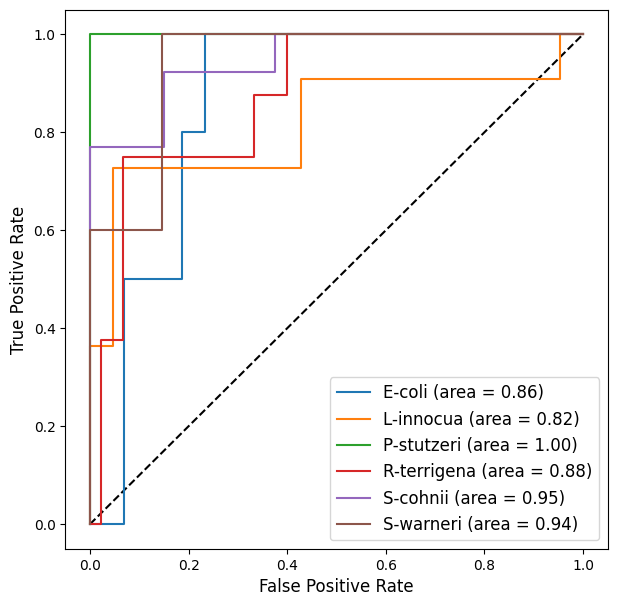

['4_Batch']


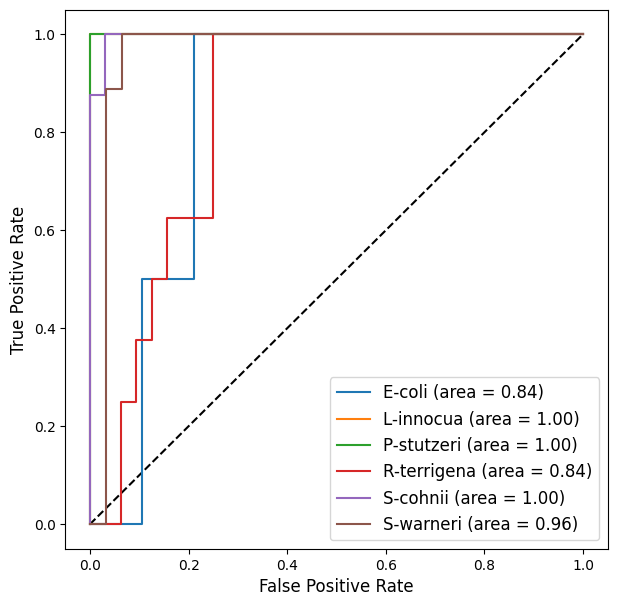

{0: array([[14,  0,  0,  5,  0,  0],
       [ 0,  5,  0,  0,  0,  1],
       [ 0,  0, 10,  0,  0,  0],
       [ 1,  0,  0, 10,  0,  0],
       [ 0,  3,  0,  0,  5,  0],
       [ 0,  0,  0,  0,  0, 12]]), 1: array([[ 3,  0,  0,  9,  0,  0],
       [ 1, 12,  0,  0,  0,  2],
       [ 0,  0,  9,  0,  0,  0],
       [ 3,  0,  0,  8,  0,  0],
       [ 0,  0,  0,  0,  9,  1],
       [ 0,  5,  0,  0,  0,  0]]), 2: array([[ 4,  0,  0,  3,  0,  0],
       [ 0,  7,  0,  0,  0,  1],
       [ 1,  0, 10,  1,  1,  0],
       [ 3,  0,  0,  7,  0,  1],
       [ 0,  4,  0,  0,  6,  5],
       [ 0,  0,  0,  1,  0,  7]]), 3: array([[4, 0, 0, 5, 0, 0],
       [1, 8, 0, 1, 0, 2],
       [0, 0, 6, 0, 0, 0],
       [3, 0, 0, 5, 1, 0],
       [0, 0, 0, 0, 8, 0],
       [0, 1, 0, 0, 2, 9]]), 4: array([[ 8,  0,  0,  1,  0,  0],
       [ 0, 13,  0,  0,  1,  0],
       [ 0,  0,  8,  0,  0,  0],
       [ 3,  1,  0,  3,  0,  1],
       [ 0,  0,  0,  0,  7,  0],
       [ 0,  2,  0,  0,  2,  4]]), 5: array([[ 0,  0,  

In [24]:
### classification with cross-validation at batch-level
from sklearn.model_selection import GroupKFold
k = len(uni_batches)
kf = GroupKFold(n_splits=k)

label_pred = np.zeros_like(labels)
cmat_inter = dict()
bacc_inter = np.zeros((k))
auc_inter = np.zeros((k))
for i, (ix_train, ix_test) in enumerate(kf.split(spec, labels, batches)):
    x_train, y_train = spec[ix_train, :], labels[ix_train]
    x_test, y_test = spec[ix_test, :], labels[ix_test]
    
    print(np.unique(batches[ix_test]))
          
    LDA_CV = LDA()
    LDA_CV.fit(x_train, y_train)
    label_pred[ix_test] = LDA_CV.predict(x_test)
    label_score = LDA_CV.decision_function(x_test)
    cmat_inter[i], bacc_inter[i], auc_inter[i] = my_evaluation(y_test, label_pred[ix_test], label_score, cmat_display=False, title=np.unique(batches[ix_test]))

print(cmat_inter)
print(bacc_inter)
print(auc_inter)

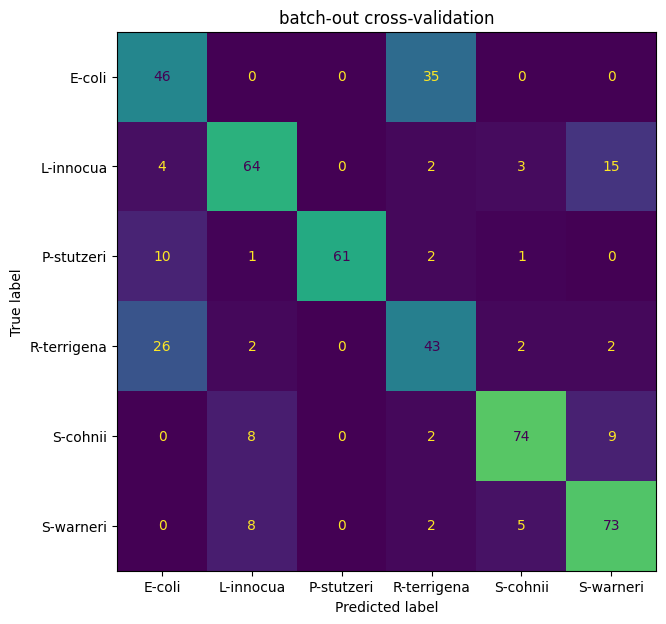

[[46  0  0 35  0  0]
 [ 4 64  0  2  3 15]
 [10  1 61  2  1  0]
 [26  2  0 43  2  2]
 [ 0  8  0  2 74  9]
 [ 0  8  0  2  5 73]]
0.7178475012973221


/opt/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [25]:
cmat_all, bacc_all, _ = my_evaluation(labels, label_pred, None, get_roc=False, title='batch-out cross-validation')
print(cmat_all)
print(bacc_all)

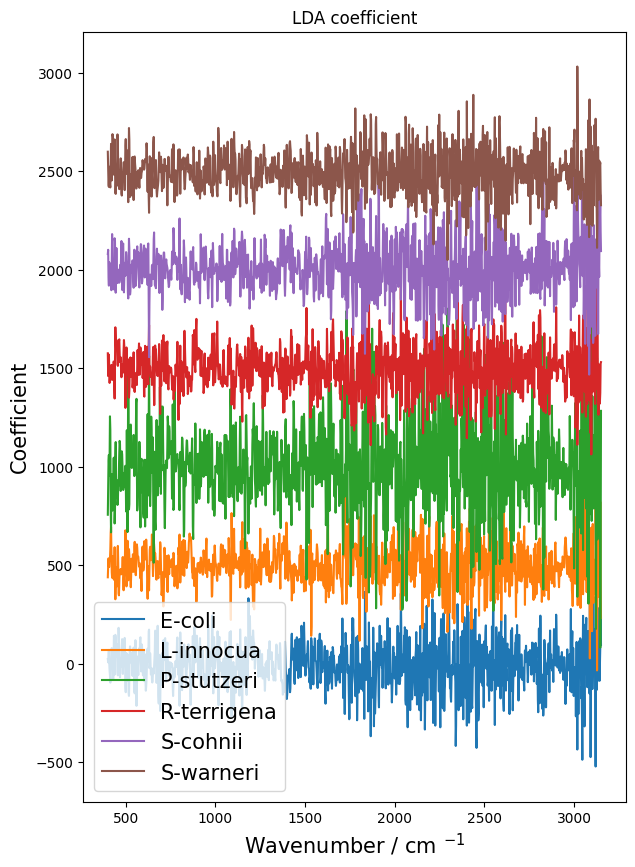

In [26]:
### feature importance
coef = LDA_CV.coef_
plt.figure(figsize=(7, 10))
for i in range(coef.shape[0]):
    plt.plot(wn, coef[i,:]+i*500, label=model_LDA.classes_[i])

plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Coefficient', fontsize=15)
plt.title('LDA coefficient')
plt.legend(loc='lower left', fontsize=15)
plt.show()